In [1]:
import re
import pandas as pd

In [2]:
log_pattern = re.compile(
    r'^(?P<Date>\d{6})\s+(?P<Time>\d{6})\s+(?P<Pid>\d+)\s+'
    r'(?P<Level>[A-Z]+)\s+(?P<Component>[^:]+):\s+(?P<Content>.*)$'
)

parsed_rows = []
malformed = []

with open("HDFS.log", "r", errors="replace") as f:
    for i, line in enumerate(f):
        match = log_pattern.match(line.strip())
        if match:
            parsed_rows.append(match.groupdict())
        else:
            malformed.append((i, line))

df = pd.DataFrame(parsed_rows)
print(f"Parsed: {len(df)}, Malformed: {len(malformed)}")

Parsed: 11175629, Malformed: 0


In [3]:
block_id_pattern = re.compile(r'(blk_-?\d+)')

df.head()

,Date,Time,Pid,Level,Component,Content
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...


In [4]:
def extract_block_id(content):
    match_result = block_id_pattern.search(content)
    if match_result:
        return match_result.group(1)
    else :
        return None

df['BlockId'] = df['Content'].apply(extract_block_id)

In [5]:
df.head()

,Date,Time,Pid,Level,Component,Content,BlockId
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906


In [6]:
missing_count = df['BlockId'].isnull().sum()
missing_count

np.int64(0)

In [7]:
print(df[['Content', "BlockId"]].head(10))

                                             Content                   BlockId
0  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906
1  BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...  blk_-1608999687919862906
2  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906
3  Receiving block blk_-1608999687919862906 src: ...  blk_-1608999687919862906
4  PacketResponder 1 for block blk_-1608999687919...  blk_-1608999687919862906
5  PacketResponder 2 for block blk_-1608999687919...  blk_-1608999687919862906
6  Received block blk_-1608999687919862906 of siz...  blk_-1608999687919862906
7  Received block blk_-1608999687919862906 of siz...  blk_-1608999687919862906
8  PacketResponder 0 for block blk_-1608999687919...  blk_-1608999687919862906
9  Received block blk_-1608999687919862906 of siz...  blk_-1608999687919862906


In [8]:
anamoly_labels = pd.read_csv("./preprocessed/anomaly_label.csv")
anamoly_labels.head()

,BlockId,Label
0,blk_-1608999687919862906,Normal
1,blk_7503483334202473044,Normal
2,blk_-3544583377289625738,Anomaly
3,blk_-9073992586687739851,Normal
4,blk_7854771516489510256,Normal


In [9]:
df_labeled = df.merge(anamoly_labels, on="BlockId", how="left")
df_labeled.head(10)

,Date,Time,Pid,Level,Component,Content,BlockId,Label
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Normal
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,Normal
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Normal
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Normal
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,Normal
5,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1608999687919...,blk_-1608999687919862906,Normal
6,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Normal
7,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Normal
8,081109,203519,147,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1608999687919...,blk_-1608999687919862906,Normal
9,081109,203519,147,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Normal


In [10]:
missing_labels_after_merge = df_labeled['Label'].isnull().sum()
print(missing_labels_after_merge)
print(df_labeled[['BlockId', 'Label']].head(10))


0
                    BlockId   Label
0  blk_-1608999687919862906  Normal
1  blk_-1608999687919862906  Normal
2  blk_-1608999687919862906  Normal
3  blk_-1608999687919862906  Normal
4  blk_-1608999687919862906  Normal
5  blk_-1608999687919862906  Normal
6  blk_-1608999687919862906  Normal
7  blk_-1608999687919862906  Normal
8  blk_-1608999687919862906  Normal
9  blk_-1608999687919862906  Normal


In [11]:
events_per_block = df_labeled.groupby("BlockId").size()
events_per_block = events_per_block.reset_index(name="EventCount")

labeled_events = events_per_block.merge(anamoly_labels, on="BlockId", how="left")
print(labeled_events.head(10))

                    BlockId  EventCount   Label
0  blk_-1000002529962039464          13  Normal
1   blk_-100000266894974466          28  Normal
2  blk_-1000007292892887521          13  Normal
3  blk_-1000014584150379967          29  Normal
4  blk_-1000028658773048709          19  Normal
5   blk_-100004553717737248          13  Normal
6  blk_-1000054577281647820          30  Normal
7  blk_-1000057191487947536          19  Normal
8  blk_-1000083860370843431          23  Normal
9  blk_-1000095285706020638          24  Normal


In [12]:
summary = labeled_events.groupby("Label")["EventCount"].describe()
print(summary)

            count       mean        std   min   25%   50%   75%    max
Label                                                                 
Anomaly   16838.0  17.119017  12.409644   2.0   4.0  20.0  26.0  284.0
Normal   558223.0  19.503637   4.775583  13.0  19.0  19.0  20.0  298.0


In [13]:
from drain3 import TemplateMiner

miner = TemplateMiner()

# Testing with sample rows
sample_df = df.head(50000).copy()

config file not found: drain3.ini


In [14]:
templates = []
cluster_ids = []

for content in sample_df['Content']:
    result = miner.add_log_message(content)
    templates.append(result['template_mined'])
    cluster_ids.append(result['cluster_id'])

sample_df['Template'] = templates
sample_df['ClusterId'] = cluster_ids

sample_df.head(10)

,Date,Time,Pid,Level,Component,Content,BlockId,Template,ClusterId
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block blk_-1608999687919862906 src: ...,1
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,2
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block blk_-1608999687919862906 src: ...,1
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block blk_-1608999687919862906 src: ...,1
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder 1 for block blk_-1608999687919...,3
5,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder <*> for block blk_-16089996879...,3
6,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Received block blk_-1608999687919862906 of siz...,4
7,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Received block blk_-1608999687919862906 of siz...,4
8,081109,203519,147,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder <*> for block blk_-16089996879...,3
9,081109,203519,147,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Received block blk_-1608999687919862906 of siz...,4


In [15]:
full_templates = []
full_cluster_ids = []

for content in df['Content']:
    result = miner.add_log_message(content)
    full_templates.append(result['template_mined'])
    full_cluster_ids.append(result['cluster_id'])

df['Template'] = full_templates
df['ClusterId'] = full_cluster_ids

df['BlockId'] = df['Content'].apply(extract_block_id)
df.head(10)

,Date,Time,Pid,Level,Component,Content,BlockId,Template,ClusterId
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block <*> src: <*> dest: <*>,1
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,BLOCK* NameSystem.allocateBlock: <*> <*>,2
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block <*> src: <*> dest: <*>,1
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block <*> src: <*> dest: <*>,1
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder <*> for block <*> terminating,3
5,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 2 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder <*> for block <*> terminating,3
6,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Received block <*> of size <*> from <*>,4
7,081109,203519,145,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Received block <*> of size <*> from <*>,4
8,081109,203519,147,INFO,dfs.DataNode$PacketResponder,PacketResponder 0 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder <*> for block <*> terminating,3
9,081109,203519,147,INFO,dfs.DataNode$PacketResponder,Received block blk_-1608999687919862906 of siz...,blk_-1608999687919862906,Received block <*> of size <*> from <*>,4


In [16]:
df_full = df.merge(anamoly_labels, on='BlockId', how='left')

template_label_counts = df_full.groupby(["Template", "Label"]).size().unstack(fill_value=0)

In [17]:
template_label_counts.head(10)

Label,Anomaly,Normal
Template,,
10.250.13.188:50010:Exception writing block blk_3858821904894294369 to mirror 10.251.39.160:50010,1,0
10.251.194.147:50010:Failed to transfer blk_992101295951175683 to 10.251.214.112:50010 got java.io.IOException: Connection reset by peer,1,0
10.251.31.5:50010 Starting thread to transfer block blk_-1608999687919862906 to 10.251.90.64:50010,0,1
10.251.71.68:50010:Got exception while serving blk_-8781759536960110370 to /10.250.17.225:,0,1
<*> Served block <*> to <*>,11842,416884
<*> Starting thread to transfer block <*> to <*>,4371,2465
<*> Starting thread to transfer block <*> to <*> <*>,88,74
<*> Starting thread to transfer block blk_-1608999687919862906 to <*> <*>,0,3
<*> block <*> to <*>,4395,2538


In [18]:
template_label_counts["AnomalyRate"] = (
    template_label_counts.get("Anomaly", 0) /
    (template_label_counts.get("Anomaly", 0) + template_label_counts.get("Normal", 0))
)

In [19]:
template_label_counts.head(10)

Label,Anomaly,Normal,AnomalyRate
Template,,,
10.250.13.188:50010:Exception writing block blk_3858821904894294369 to mirror 10.251.39.160:50010,1,0,1.000000
10.251.194.147:50010:Failed to transfer blk_992101295951175683 to 10.251.214.112:50010 got java.io.IOException: Connection reset by peer,1,0,1.000000
10.251.31.5:50010 Starting thread to transfer block blk_-1608999687919862906 to 10.251.90.64:50010,0,1,0.000000
10.251.71.68:50010:Got exception while serving blk_-8781759536960110370 to /10.250.17.225:,0,1,0.000000
<*> Served block <*> to <*>,11842,416884,0.027621
<*> Starting thread to transfer block <*> to <*>,4371,2465,0.639409
<*> Starting thread to transfer block <*> to <*> <*>,88,74,0.543210
<*> Starting thread to transfer block blk_-1608999687919862906 to <*> <*>,0,3,0.000000
<*> block <*> to <*>,4395,2538,0.633925


In [20]:
template_label_counts["TotalCount"] = (
    template_label_counts.get("Anomaly", 0) + template_label_counts.get("Normal", 0)
)

significant_templates = template_label_counts[template_label_counts['TotalCount'] > 100]
significant_templates.head(10)

Label,Anomaly,Normal,AnomalyRate,TotalCount
Template,,,,
<*> Served block <*> to <*>,11842,416884,0.027621,428726
<*> Starting thread to transfer block <*> to <*>,4371,2465,0.639409,6836
<*> Starting thread to transfer block <*> to <*> <*>,88,74,0.543210,162
<*> block <*> to <*>,4395,2538,0.633925,6933
<*> exception while serving <*> to <*>,8259,347947,0.023186,356206
BLOCK* NameSystem.addStoredBlock: Redundant addStoredBlock request received for <*> on <*> size <*>,945,3,0.996835,948
BLOCK* NameSystem.addStoredBlock: addStoredBlock request received for <*> on <*> size <*> But it does not belong to any file.,1253,12,0.990514,1265
BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>,40256,1679485,0.023408,1719741
BLOCK* NameSystem.allocateBlock: <*> <*>,16838,558223,0.029280,575061


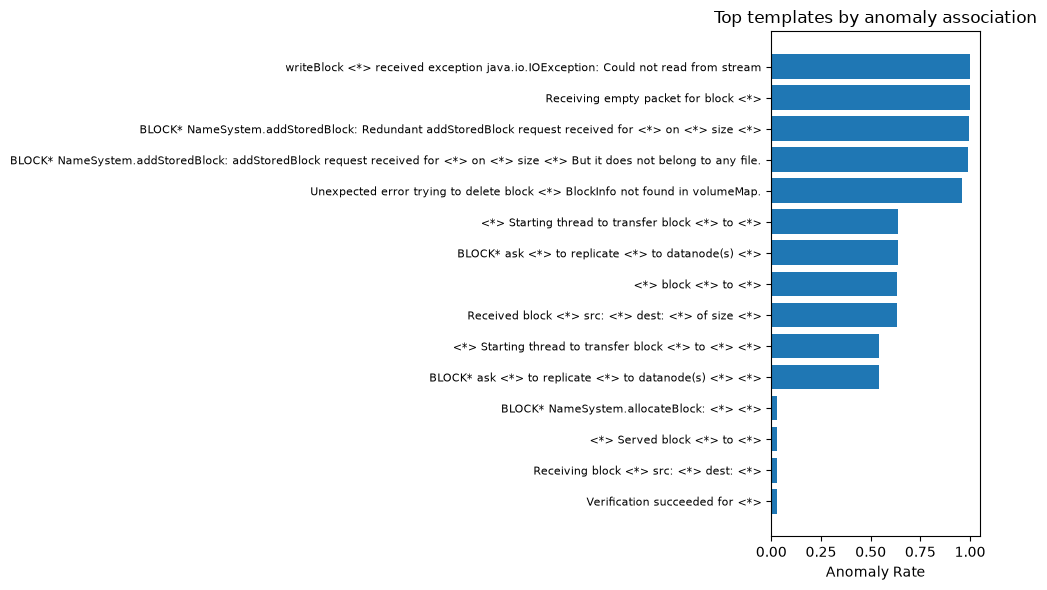

In [21]:
import matplotlib.pyplot as plt

top_templates = significant_templates.sort_values("AnomalyRate", ascending=False).head(15)

plt.figure(figsize=(10, 6))
plt.barh(range(len(top_templates)), top_templates["AnomalyRate"])
plt.yticks(range(len(top_templates)), top_templates.index, fontsize=8)
plt.xlabel("Anomaly Rate")
plt.title("Top templates by anomaly association")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [22]:
df_full.head()

,Date,Time,Pid,Level,Component,Content,BlockId,Template,ClusterId,Label
0,081109,203518,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block <*> src: <*> dest: <*>,1,Normal
1,081109,203518,35,INFO,dfs.FSNamesystem,BLOCK* NameSystem.allocateBlock: /mnt/hadoop/m...,blk_-1608999687919862906,BLOCK* NameSystem.allocateBlock: <*> <*>,2,Normal
2,081109,203519,143,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block <*> src: <*> dest: <*>,1,Normal
3,081109,203519,145,INFO,dfs.DataNode$DataXceiver,Receiving block blk_-1608999687919862906 src: ...,blk_-1608999687919862906,Receiving block <*> src: <*> dest: <*>,1,Normal
4,081109,203519,145,INFO,dfs.DataNode$PacketResponder,PacketResponder 1 for block blk_-1608999687919...,blk_-1608999687919862906,PacketResponder <*> for block <*> terminating,3,Normal


In [23]:
def build_block_documents(block_id, df_labeled):
    block_rows = df_labeled[df_labeled['BlockId'] == block_id]
    if block_rows.empty:
        return None

    label = block_rows['Label'].iloc[0]
    templates = block_rows['Template'].tolist()
    doc_text = f"BlockId: {block_id}, outcome: {label}. Events: " + "; ".join(templates)
    return doc_text

In [24]:
sample_block_ids = df_full['BlockId'].dropna().unique()[:100]

documents = []
metadatas = []
ids = []

for block_id in sample_block_ids:
    doc = build_block_documents(block_id, df_full)
    if doc:
        documents.append(doc)
        metadatas.append({"block_id": block_id, "label": df_full.loc[df_full['BlockId'] == block_id, 'Label'].iloc[0]})
        ids.append(block_id)

metadatas

[{'block_id': 'blk_-1608999687919862906', 'label': 'Normal'},
 {'block_id': 'blk_7503483334202473044', 'label': 'Normal'},
 {'block_id': 'blk_-3544583377289625738', 'label': 'Anomaly'},
 {'block_id': 'blk_-9073992586687739851', 'label': 'Normal'},
 {'block_id': 'blk_7854771516489510256', 'label': 'Normal'},
 {'block_id': 'blk_1717858812220360316', 'label': 'Normal'},
 {'block_id': 'blk_-2519617320378473615', 'label': 'Normal'},
 {'block_id': 'blk_7063315473424667801', 'label': 'Normal'},
 {'block_id': 'blk_8586544123689943463', 'label': 'Normal'},
 {'block_id': 'blk_2765344736980045501', 'label': 'Normal'},
 {'block_id': 'blk_-2900490557492272760', 'label': 'Normal'},
 {'block_id': 'blk_-50273257731426871', 'label': 'Normal'},
 {'block_id': 'blk_4394112519745907149', 'label': 'Normal'},
 {'block_id': 'blk_3640100967125688321', 'label': 'Normal'},
 {'block_id': 'blk_-40115644493265216', 'label': 'Normal'},
 {'block_id': 'blk_-8531310335568756456', 'label': 'Anomaly'},
 {'block_id': 'blk

In [26]:
from sentence_transformers import SentenceTransformer
import numpy as np

embedder = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = embedder.encode(documents, show_progress_bar=True)
embeddings = np.array(embeddings).astype("float32")

print(embeddings.shape)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

c:\Users\KarthikVenkatesan\Desktop\learning\fab-log-env\Lib\site-packages\huggingface_hub\file_download.py:150: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\KarthikVenkatesan\.cache\huggingface\hub\models--sentence-transformers--all-MiniLM-L6-v2. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/4 [00:00<?, ?it/s]

(100, 384)


In [27]:
embeddings

array([[-0.01486771,  0.0031477 , -0.02053857, ..., -0.00968271,
        -0.05567521,  0.02996829],
       [-0.01493296,  0.00531882, -0.01631491, ..., -0.01218088,
        -0.05785967,  0.02624503],
       [-0.02668846,  0.00181955, -0.00516663, ..., -0.03846131,
        -0.06105627,  0.04106956],
       ...,
       [-0.01897281,  0.00265119, -0.01622979, ..., -0.0121008 ,
        -0.05885481,  0.03161276],
       [-0.01569536,  0.00178335, -0.01821518, ..., -0.0097011 ,
        -0.06212597,  0.02699219],
       [-0.01900256,  0.00378999, -0.01527318, ..., -0.01082711,
        -0.06090657,  0.03202746]], shape=(100, 384), dtype=float32)

In [29]:
dimensions = embeddings.shape[1]
dimensions

384

In [30]:
import faiss

index = faiss.IndexFlatL2(dimensions)
index.add(embeddings)

print(index.ntotal, "vectors indexed")

100 vectors indexed


In [38]:
def semantic_search(query, index, documents, metadatas, embedder, top_k=5):
    query_embedding = embedder.encode([query]).astype("float32")
    distances, indices = index.search(query_embedding, top_k)
    results = []
    for idx in indices[0]:
        results.append({
            "document": documents[idx],
            "metadata": metadatas[idx],
        })
    return {"results": results, "distances": distances}

In [ ]:
results = semantic_search("block 354437", index, documents, metadatas, embedder, top_k=5)
print(results)

{'results': [{'document': 'BlockId: blk_7956543127401791181, outcome: Anomaly. Events: Receiving block <*> src: <*> dest: <*>; Receiving block <*> src: <*> dest: <*>; BLOCK* NameSystem.allocateBlock: <*> <*>; Receiving block <*> src: <*> dest: <*>; Received block <*> of size <*> from <*>; PacketResponder <*> for block <*> terminating; Received block <*> of size <*> from <*>; BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>; BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>; PacketResponder <*> for block <*> terminating; Received block <*> of size <*> from <*>; PacketResponder <*> for block <*> terminating; BLOCK* NameSystem.addStoredBlock: blockMap updated: <*> is added to <*> size <*>; Verification succeeded for <*>; Verification succeeded for <*>; Verification succeeded for <*>; <*> exception while serving <*> to <*>; <*> Served block <*> to <*>; <*> exception while serving <*> to <*>; <*> exception while serving <*> to <

In [ ]:
results['distances']


array([[1.3002464, 1.3293442, 1.3383234, 1.3404584, 1.3522302]],
      dtype=float32)